# Cane Corso Growth Prediction - Linear Regression

This notebook is the first experiment in the project.

The goal is to test whether age in months can be used to predict the weight of a Cane Corso using linear regression.

At this stage, the dataset is a small prototype dataset and is not real veterinary data.


## Problem Statement

Many owners of large-breed dogs want to understand whether their dog is growing in an expected way.

In this first experiment, I use a very simple regression setup:

- Input variable: age in months
- Target variable: weight in kilograms

This is only a first step. More features and better models can be added later.


## Mathematical Idea

The first model will use a simple linear regression equation:

$$ y = b_0 + b_1x $$

Where:

- $x$ is the age in months
- $y$ is the predicted weight in kilograms
- $b_0$ is the intercept
- $b_1$ is the coefficient for age


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
data_path = '../data/prototype/cane_corso_growth_sample.csv'
df = pd.read_csv(data_path)
df.head()


,dog_id,dog_name,sex,age_months,weight_kg,height_cm,activity_level,source_type
0,1,Ares,male,2,9.5,32,medium,prototype
1,1,Ares,male,3,14.2,38,medium,prototype
2,1,Ares,male,4,20.1,45,medium,prototype
3,1,Ares,male,5,26.4,51,medium,prototype
4,1,Ares,male,6,31.8,56,medium,prototype


## Initial Data Exploration

Before training a model, I first check the size, structure, and basic statistics of the dataset.

This helps me understand what data I have and whether the values look usable for a first regression experiment.

In [3]:
df.shape

(32, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dog_id          32 non-null     int64  
 1   dog_name        32 non-null     str    
 2   sex             32 non-null     str    
 3   age_months      32 non-null     int64  
 4   weight_kg       32 non-null     float64
 5   height_cm       32 non-null     int64  
 6   activity_level  32 non-null     str    
 7   source_type     32 non-null     str    
dtypes: float64(1), int64(3), str(4)
memory usage: 2.1 KB


In [5]:
df.describe()

,dog_id,age_months,weight_kg,height_cm
count,32.000000,32.000000,32.000000,32.00000
mean,2.500000,6.250000,27.437500,50.53125
std,1.135924,3.321484,12.550922,11.55627
min,1.000000,2.000000,8.100000,30.00000
25%,1.750000,3.750000,16.675000,41.50000
50%,2.500000,5.500000,27.250000,52.00000
75%,3.250000,8.500000,38.550000,61.00000
max,4.000000,12.000000,49.100000,68.00000


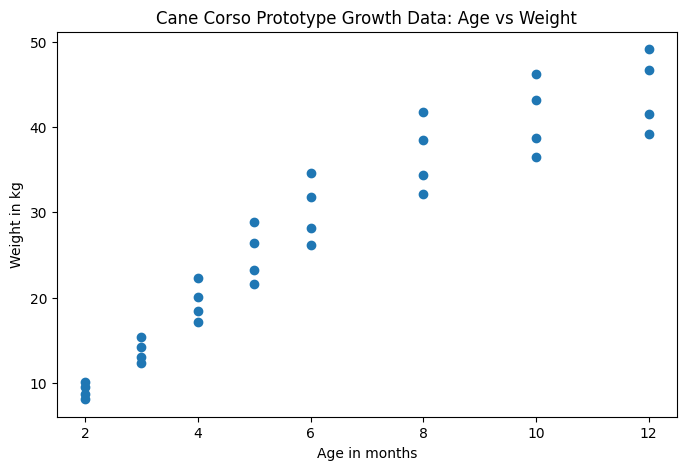

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"])
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Cane Corso Prototype Growth Data: Age vs Weight")
plt.show()

## First Linear Regression Model

In this section, I train the first simple linear regression model.

The model uses age in months as the input feature and weight in kilograms as the target value.

In [7]:
X = df[["age_months"]]
y = df["weight_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "actual_weight_kg": y_test.values,
    "predicted_weight_kg": y_pred.round(2)
})

predictions

,actual_weight_kg,predicted_weight_kg
0,32.1,34.79
1,41.5,49.03
2,8.1,13.43
3,15.4,16.99
4,8.7,13.43
5,13.1,16.99
6,36.5,41.91
7,12.3,16.99


In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,4.480092
1,MSE,22.933348
2,RMSE,4.788877
3,R2 Score,0.855636


In [9]:
print("Intercept:", model.intercept_)
print("Age coefficient:", model.coef_[0])

Intercept: 6.308015768725344
Age coefficient: 3.5599211563731954


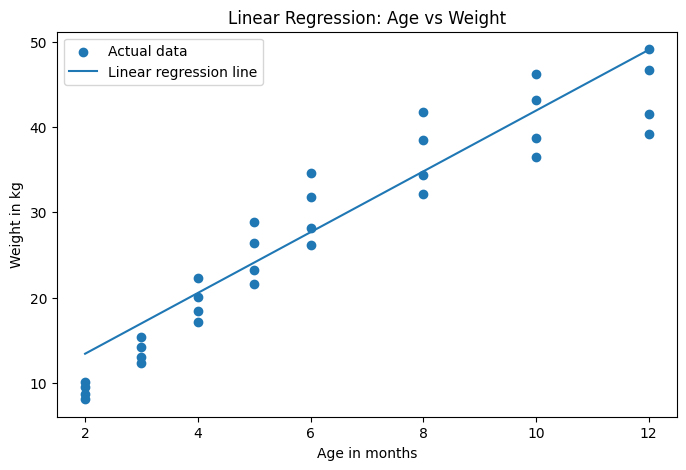

In [10]:
age_values = pd.DataFrame({
    "age_months": sorted(df["age_months"].unique())
})

predicted_weights = model.predict(age_values)

plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"], label="Actual data")
plt.plot(age_values["age_months"], predicted_weights, label="Linear regression line")
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Linear Regression: Age vs Weight")
plt.legend()
plt.show()

## First Linear Regression Model

In this section, I train the first simple linear regression model.

The model uses age in months as the input feature and weight in kilograms as the target value.

In [11]:
X = df[["age_months"]]
y = df["weight_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "actual_weight_kg": y_test.values,
    "predicted_weight_kg": y_pred.round(2)
})

predictions

,actual_weight_kg,predicted_weight_kg
0,32.1,34.79
1,41.5,49.03
2,8.1,13.43
3,15.4,16.99
4,8.7,13.43
5,13.1,16.99
6,36.5,41.91
7,12.3,16.99


In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,4.480092
1,MSE,22.933348
2,RMSE,4.788877
3,R2 Score,0.855636


In [13]:
print("Intercept:", model.intercept_)
print("Age coefficient:", model.coef_[0])

Intercept: 6.308015768725344
Age coefficient: 3.5599211563731954


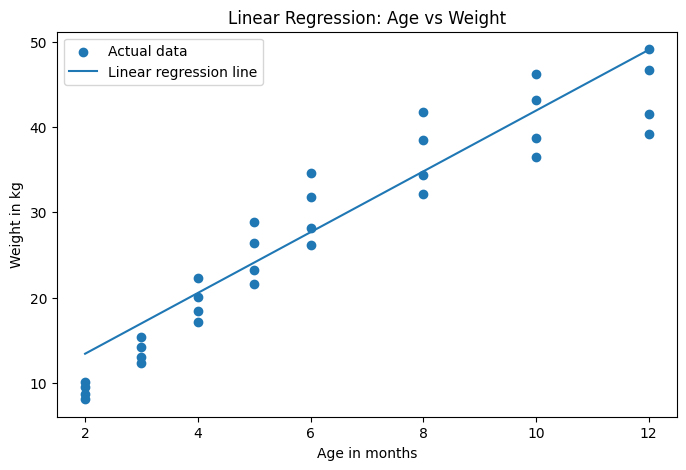

In [14]:
age_values = pd.DataFrame({
    "age_months": sorted(df["age_months"].unique())
})

predicted_weights = model.predict(age_values)

plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"], label="Actual data")
plt.plot(age_values["age_months"], predicted_weights, label="Linear regression line")
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Linear Regression: Age vs Weight")
plt.legend()
plt.show()

## Result Interpretation

The first linear regression model shows how weight changes with age in the prototype dataset.

The model uses only one feature: age in months. Because of this, it is easy to understand, but it is also limited.

The evaluation metrics help me check how close the predictions are to the actual values.

- MAE shows the average prediction error in kilograms.
- RMSE gives more weight to larger errors.
- R2 Score shows how much of the variation in weight is explained by age.

This first experiment is useful as a baseline model. However, real dog growth depends on more factors than age alone, such as sex, genetics, nutrition, activity level, health, and environment.

Because of that, this model should not be used as a veterinary tool. It is only a first educational machine learning experiment.

## Polynomial Regression

The previous model used a straight line to predict weight from age.

Dog growth is usually not perfectly linear. Puppies often grow faster in the first months and then the growth speed becomes slower.

For this reason, I will test a polynomial regression model as an extension of simple linear regression.

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [16]:
X = df[["age_months"]]
y = df["weight_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

poly_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=2)),
    ("linear_regression", LinearRegression())
])

poly_model.fit(X_train, y_train)

poly_y_pred = poly_model.predict(X_test)

poly_predictions = pd.DataFrame({
    "actual_weight_kg": y_test.values,
    "predicted_weight_kg": poly_y_pred.round(2)
})

poly_predictions

,actual_weight_kg,predicted_weight_kg
0,32.1,37.35
1,41.5,45.40
2,8.1,8.47
3,15.4,14.69
4,8.7,8.47
5,13.1,14.69
6,36.5,42.49
7,12.3,14.69


In [17]:
poly_mae = mean_absolute_error(y_test, poly_y_pred)
poly_mse = mean_squared_error(y_test, poly_y_pred)
poly_rmse = poly_mse ** 0.5
poly_r2 = r2_score(y_test, poly_y_pred)

poly_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Polynomial Regression": [poly_mae, poly_mse, poly_rmse, poly_r2]
})

poly_metrics

,Metric,Polynomial Regression
0,MAE,2.553559
1,MSE,10.949067
2,RMSE,3.308937
3,R2 Score,0.931076


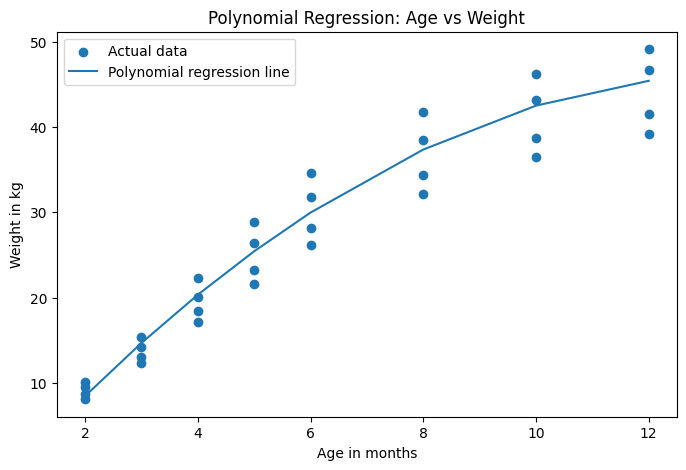

In [18]:
age_range = pd.DataFrame({
    "age_months": sorted(df["age_months"].unique())
})

poly_predicted_weights = poly_model.predict(age_range)

plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"], label="Actual data")
plt.plot(age_range["age_months"], poly_predicted_weights, label="Polynomial regression line")
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Polynomial Regression: Age vs Weight")
plt.legend()
plt.show()

### Polynomial Regression Interpretation

The polynomial regression model allows the prediction curve to bend instead of using only a straight line.

This can be useful for growth data because growth is often faster at early ages and slower later.

However, this is still a simple model because it uses only age in months as the input feature. More realistic models should also include sex, height, activity level, nutrition, and other factors.